FIRST, LET'S ANALYZE OUR DATA

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [36]:
df = pd.read_csv('../data/train.csv', sep=',')
df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [38]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


FREQUENCY DISTRIBUTION

1.8828757597682129


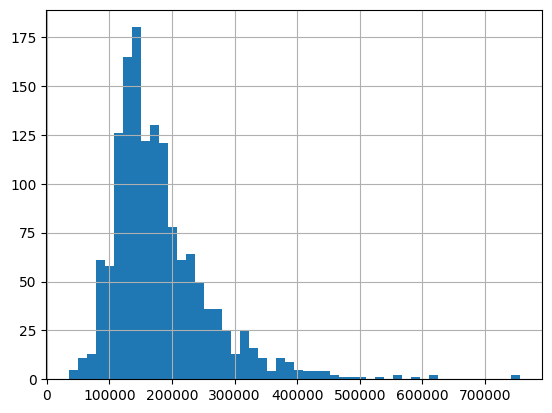

In [39]:
df['SalePrice'].hist(bins=50)
print(df['SalePrice'].skew())

In [40]:
print(df['SalePrice'].skew())

1.8828757597682129



LET'S FIND THE CORRELATION OF THE FEATURES WITH THE TARGET

In [41]:
num_cols = df.select_dtypes(include=[np.number])
correlations = num_cols.corr()['SalePrice'].abs().sort_values(ascending=False)
correlations.head(11)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

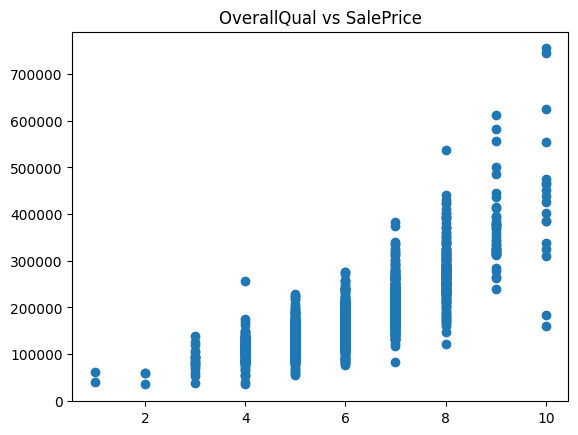

In [42]:
plt.scatter(df['OverallQual'], df['SalePrice'])
plt.title('OverallQual vs SalePrice')
plt.show()

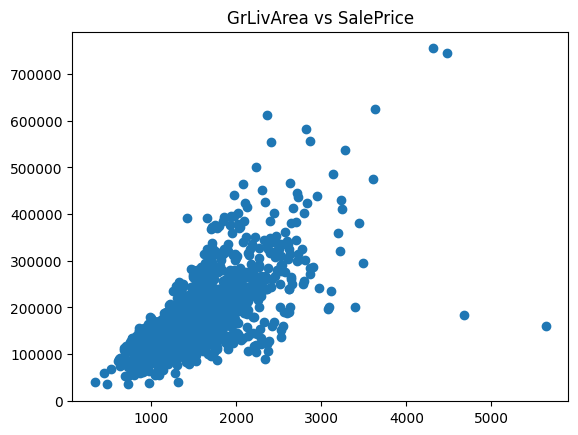

In [43]:
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.title('GrLivArea vs SalePrice')
plt.show()

outliers count - 2


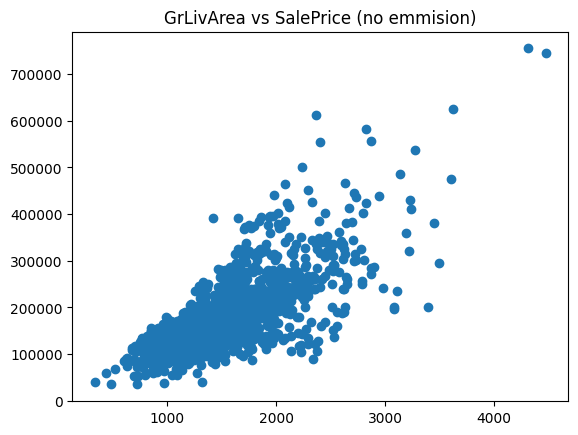

In [44]:
outliers = df[((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200_000))]
print(f'outliers count - {len(outliers)}')

df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200_000))]

plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.title('GrLivArea vs SalePrice (no emmision)')
plt.show()

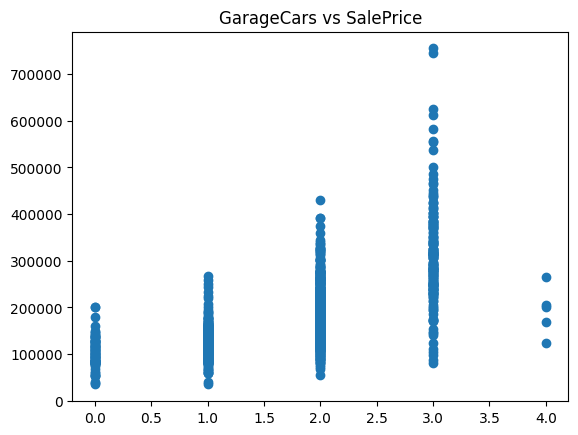

In [45]:
plt.scatter(df['GarageCars'], df['SalePrice'])
plt.title('GarageCars vs SalePrice')
plt.show()

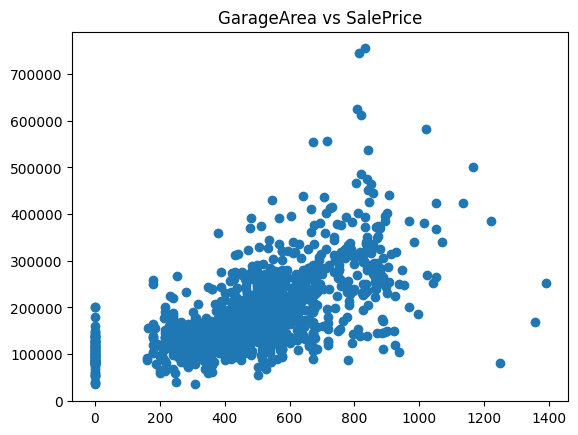

In [46]:
plt.scatter(df['GarageArea'], df['SalePrice'])
plt.title('GarageArea vs SalePrice')
plt.show()

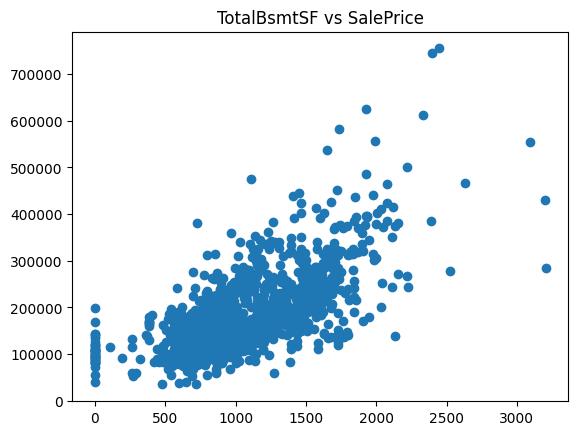

In [47]:
plt.scatter(df['TotalBsmtSF'], df['SalePrice'])
plt.title('TotalBsmtSF vs SalePrice')
plt.show()

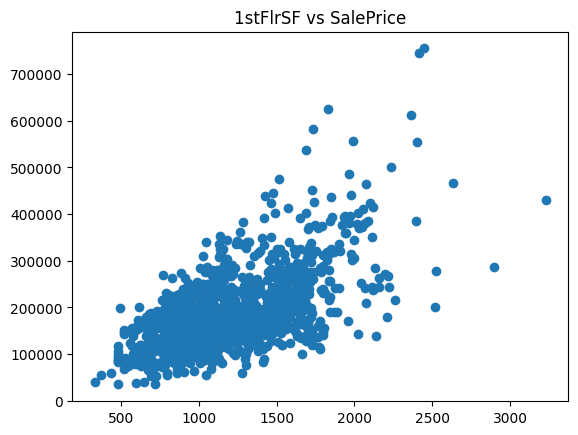

In [48]:
plt.scatter(df['1stFlrSF'], df['SalePrice'])
plt.title('1stFlrSF vs SalePrice')
plt.show()

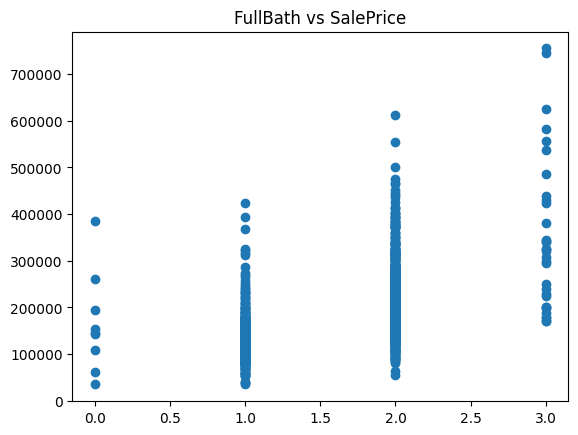

In [49]:
plt.scatter(df['FullBath'], df['SalePrice'])
plt.title('FullBath vs SalePrice')
plt.show()

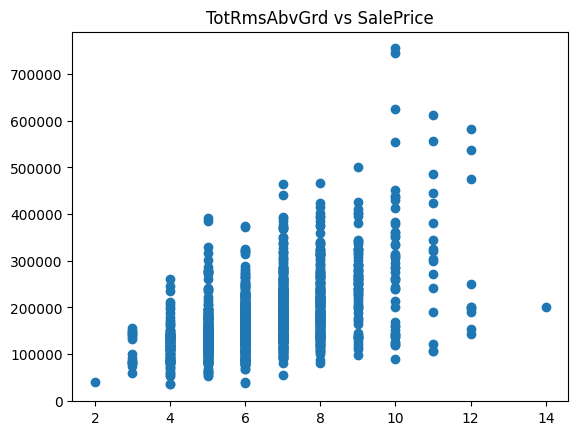

In [50]:
plt.scatter(df['TotRmsAbvGrd'], df['SalePrice'])
plt.title('TotRmsAbvGrd vs SalePrice')
plt.show()

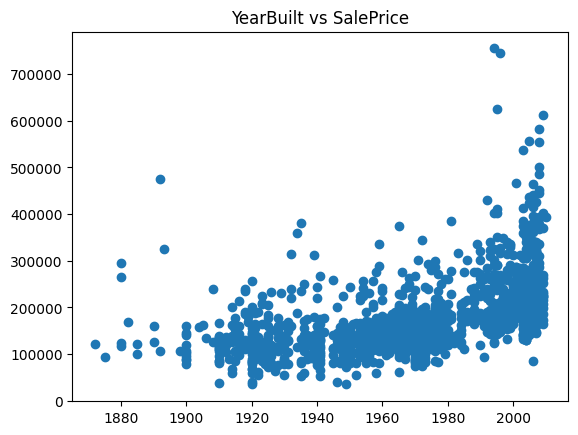

In [51]:
plt.scatter(df['YearBuilt'], df['SalePrice'])
plt.title('YearBuilt vs SalePrice')
plt.show()

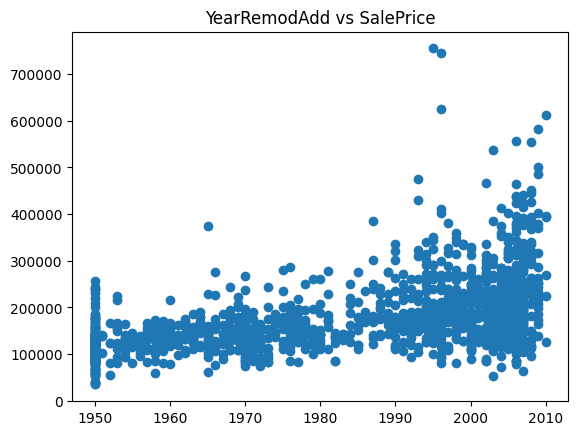

In [52]:
plt.scatter(df['YearRemodAdd'], df['SalePrice'])
plt.title('YearRemodAdd vs SalePrice')
plt.show()

HOW MANY ZERO VALUES DO WE HAVE ?

In [53]:
df.isnull().sum(axis=0).sort_values(ascending=False)

PoolQC           1452
MiscFeature      1404
Alley            1367
Fence            1177
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [54]:
df = df.dropna(thresh=len(df)/2, axis=1)
df.isnull().sum(axis=0).sort_values(ascending=False)

FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageQual        81
GarageFinish      81
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 76, dtype: int64

WORK WITH GARAGES

In [55]:
garage_columns = [g for g in df.columns if g.startswith('Garage')]
df[garage_columns].dtypes

GarageType          str
GarageYrBlt     float64
GarageFinish        str
GarageCars        int64
GarageArea        int64
GarageQual          str
GarageCond          str
dtype: object

In [56]:
df[garage_columns].isna().sum()

GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageCars       0
GarageArea       0
GarageQual      81
GarageCond      81
dtype: int64

In [57]:
(df['GarageCars'] == 0).sum()

np.int64(81)

In [58]:
(df['GarageArea'] == 0).sum()

np.int64(81)

In [59]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [60]:
garage_str_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

for col in garage_str_cols:
    df[col] = df[col].fillna('None')
    
df.isna().sum().sort_values(ascending=False)

FireplaceQu      690
LotFrontage      259
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 76, dtype: int64

WORK WITH FIREPLACES

In [71]:
fireplace = [f for f in df.columns if f.startswith('Fire')]
df[fireplace].isna().sum()
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenP

In [75]:
df[(df['Fireplaces'] == 0) & (df['FireplaceQu'].isna())].shape
df['PoolArea'].iloc[512]

np.int64(0)

In [63]:
df['FireplaceQu'] =  df['FireplaceQu'].fillna('None')
df.isna().sum(axis=0).sort_values(ascending=False)

LotFrontage      259
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 76, dtype: int64

In [64]:
df['LotFrontage'] = df.groupby(['Neighborhood'])['LotFrontage'].transform(lambda x: x.fillna(x.median()))
df.isna().sum().sort_values(ascending=False)

BsmtExposure     38
BsmtFinType2     38
BsmtCond         37
BsmtQual         37
BsmtFinType1     37
                 ..
MoSold            0
YrSold            0
SaleType          0
SaleCondition     0
SalePrice         0
Length: 76, dtype: int64

In [65]:
bsmt_cols = [b for b in df.columns if b.startswith('Bsmt')]
df[bsmt_cols] = df[bsmt_cols].fillna('None')

df.isna().sum(axis=0).sort_values(ascending=False)

MasVnrArea       8
Electrical       1
Id               0
MSSubClass       0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

In [66]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [67]:
electrical_mode = df['Electrical'].mode()[0]
df['Electrical'] = df['Electrical'].fillna(electrical_mode)
df.isna().sum(axis=0).sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

LET'S SAVE INTO THE FILE OUR CLEAN DATA

In [68]:
df.to_csv('../data/no-passes-data.csv', index=False)